<a href="https://colab.research.google.com/github/DarkLyng/Challenge-TelecomX_P2/blob/main/Telecom_X_P2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🛠️ Preparación de los Datos**

In [197]:
#Bibliotecas

import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [198]:
datos = pd.read_csv("/content/df_normalizado.csv")
datos

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,1,0,1,1,0,One year,1,Mailed check,65.60,593.30
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,0,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,9987-LUTYD,0,Female,0,0,0,13,1,0,DSL,...,0,0,1,0,0,One year,0,Mailed check,55.15,742.90
7028,9992-RRAMN,1,Male,0,1,0,22,1,1,Fiber optic,...,0,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70
7029,9992-UJOEL,0,Male,0,0,0,2,1,0,DSL,...,1,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75
7030,9993-LHIEB,0,Male,0,1,1,67,1,0,DSL,...,0,1,1,0,1,Two year,0,Mailed check,67.85,4627.65


In [199]:
#Eliminar columnas que no aportan valor al análisis
datos = datos.drop("customerID", axis=1 )
datos.head()

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.30
1,0,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40
2,1,Male,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85
3,1,Male,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85
4,1,Female,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40


# **Encoding**

# **Verificacion de la proporción de cancelación**

In [200]:
datos["Churn"].value_counts()

,count
Churn,
0,5163
1,1869


In [201]:
datos["Churn"].value_counts(normalize=True)*100

,proportion
Churn,
0,73.421502
1,26.578498


# **Encoding y Análisis de Correlación**

In [202]:
#Separamos en varaibles explicativas y variable respuesta
#X = datos.drop('Churn', axis = 1) # Variables Explicactivas
#y = datos['Churn']                # Variable Respuesta

In [203]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = pd.Series(label_encoder.fit_transform(y)) #la serie y en serie

In [204]:
variables_categoricas = [
    "customer.gender",
    "customer.SeniorCitizen",
    "customer.Partner",
    "customer.Dependents",
    "phone.PhoneService",
    "phone.MultipleLines",
    "internet.InternetService",
    "internet.OnlineSecurity",
    "internet.DeviceProtection",
    "internet.TechSupport",
    "internet.StreamingTV",
    "internet.StreamingMovies",
    "account.Contract",
    "account.PaperlessBilling",
    "account.PaymentMethod"
]

In [205]:
variables_numericas = [
    "customer.tenure",
    "account.Charges.Monthly",
    "account.Charges.Total",
    "Cuentas_Diarias"
]

In [206]:
# Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning.
# método de codificación "one-hot encoding".

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer

one_hot = make_column_transformer((OneHotEncoder(drop = 'if_binary'), ['customer.gender', 'internet.InternetService',
                                  'account.Contract', 'account.PaymentMethod']),
                                  remainder= 'passthrough',
                                  sparse_threshold= 0,
                                  force_int_remainder_cols= False)

In [207]:
# Se ajusta con TODO el dataset (menos la columna objetivo)
one_hot.fit(datos.drop('Churn', axis=1))

# Se transforma TODO el dataset
datos_encoded = one_hot.transform(datos.drop('Churn', axis=1))

#Recuperar los nombres de las columnas
nombres_columnas = one_hot.get_feature_names_out()

In [208]:
#crear el data frame con los nombres correctos
X = pd.DataFrame(datos_encoded, columns = nombres_columnas)

#variable objetivo
y = datos['Churn']

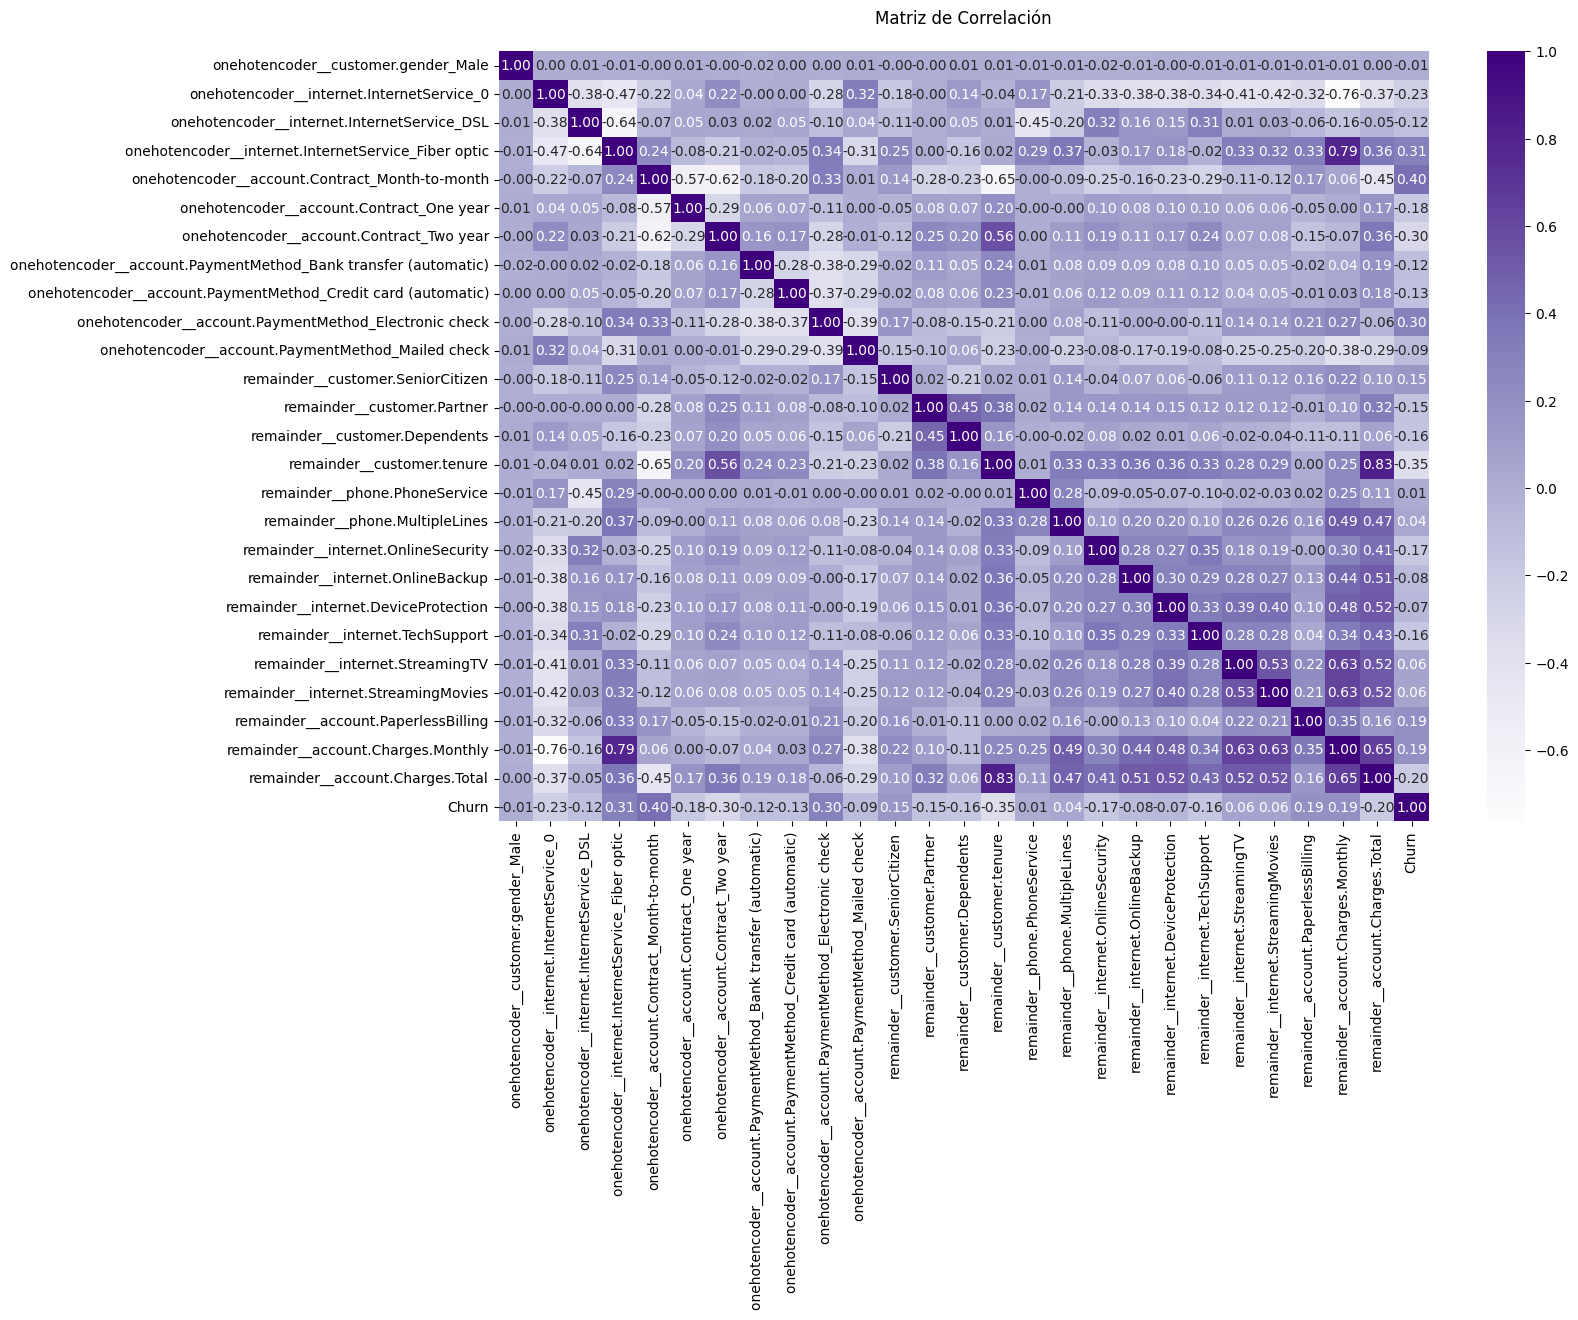

,Churn
Churn,1.000000
onehotencoder__account.Contract_Month-to-month,0.404565
onehotencoder__internet.InternetService_Fiber optic,0.307463
onehotencoder__account.PaymentMethod_Electronic check,0.301455
remainder__account.Charges.Monthly,0.192858
remainder__account.PaperlessBilling,0.191454
remainder__customer.SeniorCitizen,0.150541
remainder__internet.StreamingTV,0.063254
remainder__internet.StreamingMovies,0.060860
remainder__phone.MultipleLines,0.040033


In [209]:
#Gráfica de correlación
plt.figure(figsize=(15,10))
sns.heatmap(pd.concat([X, y], axis = 1).corr(), cmap='Purples', annot = True, fmt = ".2f")
plt.title("Matriz de Correlación", pad=20)
plt.show()

pd.concat([X, y], axis=1).corr()['Churn'].sort_values(ascending=False)

**El heatmap (mapa de calor) es la forma más eficiente de leer una matriz de correlación cuando hay muchas variables, indica que cada variable tiene una correlación perfecta consigo misma, es decir 1.0:**

* **Colores intensos (1.0):** Indica una relación directa total, si una sube, la otra también.

* **Colores menos intensos (-1.0):** Indica una relación inversa perfecta, es decir, detectan variables que se comportan de forma opuesta.

* **Blanco o colores claros (0):** Indica que hay falta de relación lineal, por lo tanto, los cambios en una variable no ayudan en nada a predecir la otra.

# **Análisis Dirigido**

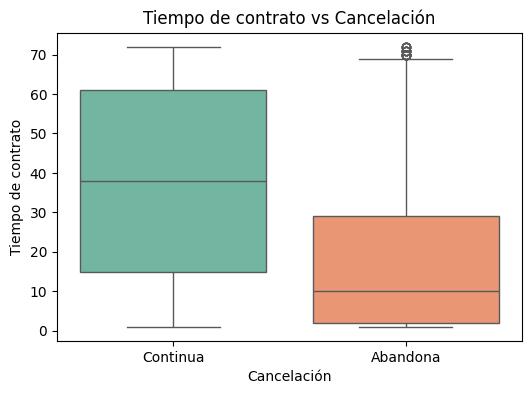

In [210]:
#Tiempo de contrato (ternure) vs cancelación (churn)

valores_churn = datos["Churn"].map({0:"Continua",1:"Abandona"})

plt.figure(figsize = (6,4))
sns.boxplot(data = datos, x = valores_churn,
            y = "customer.tenure",
            hue = valores_churn,
            palette = "Set2",
            )

plt.title("Tiempo de contrato vs Cancelación")
plt.xlabel("Cancelación")
plt.ylabel("Tiempo de contrato")
plt.show()

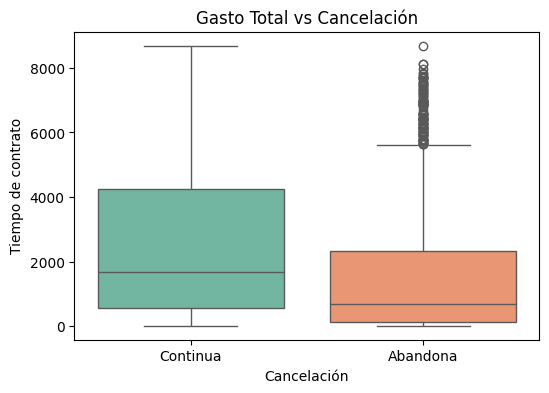

In [211]:
#Gasto total vs cancelación

valores_churn = datos["Churn"].map({0:"Continua",1:"Abandona"})

plt.figure(figsize = (6,4))
sns.boxplot(data = datos, x = valores_churn,
            y = "account.Charges.Total",
            hue = valores_churn,
            palette = "Set2",
            )
plt.title("Gasto Total vs Cancelación")
plt.xlabel("Cancelación")
plt.ylabel("Tiempo de contrato")
plt.show()

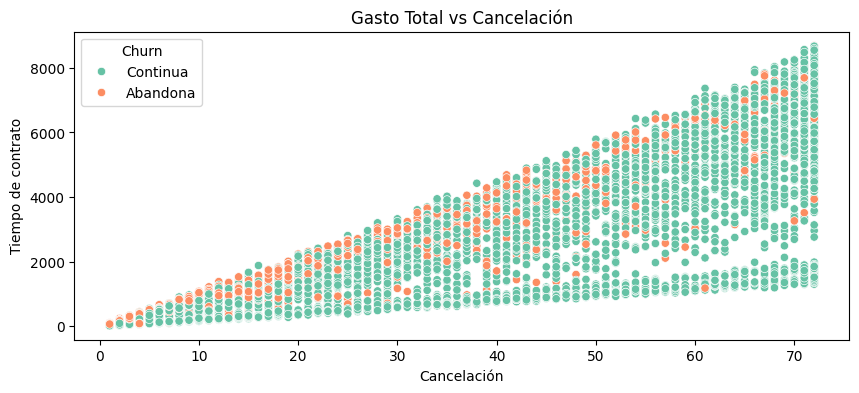

In [212]:


valores_churn = datos["Churn"].map({0:"Continua",1:"Abandona"})

plt.figure(figsize = (10,4))
sns.scatterplot(data = datos, x = "customer.tenure",
            y = "account.Charges.Total",
            hue = valores_churn,
            palette = "Set2",
            )
plt.title("Gasto Total vs Cancelación")
plt.xlabel("Cancelación")
plt.ylabel("Tiempo de contrato")
plt.show()

# **Separación de datos**

In [213]:
# Dividir los datos de prueba de los datos de entrenamiento

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, random_state = 5)

y_train.value_counts(normalize=True)

,proportion
Churn,
0,0.734168
1,0.265832


**Se puede observar que hay un gran desbalance, por lo tanto, es necesario utilizar métodos de balanceo.**

# **Normalización**

In [214]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

# **Balanceo**

**Oversampling Aleatorio**

In [215]:
from imblearn.over_sampling import RandomOverSampler

over_sampling_aleatorio = RandomOverSampler(random_state=5)
X_train_over, y_train_over = over_sampling_aleatorio.fit_resample(X_train_scaler, y_train)

y_train_over.value_counts()

,count
Churn,
0,3872
1,3872


In [216]:
y_train_over.value_counts(normalize = True)

,proportion
Churn,
0,0.5
1,0.5


**Oversampling SMOTE**

In [217]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaler, y_train)

y_train_smote.value_counts()

,count
Churn,
0,3872
1,3872


In [218]:
y_train_smote.value_counts(normalize = True)

,proportion
Churn,
0,0.5
1,0.5


**Undersamping**

In [219]:
from imblearn.under_sampling import RandomUnderSampler

under_sampling = RandomUnderSampler(random_state = 5)
X_train_under, y_train_under = under_sampling.fit_resample(X_train_scaler, y_train)

y_train_under.value_counts()

,count
Churn,
0,1402
1,1402


In [220]:
y_train_under.value_counts(normalize = True)

,proportion
Churn,
0,0.5
1,0.5


Se observa que se logró aplicar correctamente para todos métodos.

Se aumentó la clase minoritaria (1 / abandonó) hasta alcanzar la mayoritaria(0 / continúo), es decir, ambos tienen la misma cantidad de ejemplos, esto quiere decir que se confirma que el oversampling y undersampling se aplicaron correctamente.

Accuracy: 0.7343572241183163
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1291
           1       0.00      0.00      0.00       467

    accuracy                           0.73      1758
   macro avg       0.37      0.50      0.42      1758
weighted avg       0.54      0.73      0.62      1758

[[1291    0]
 [ 467    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


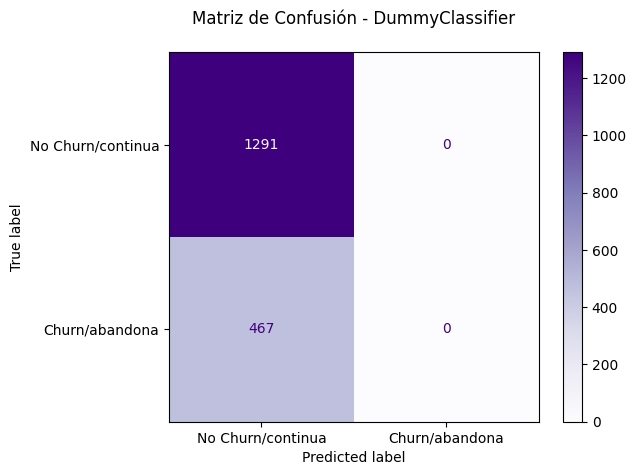

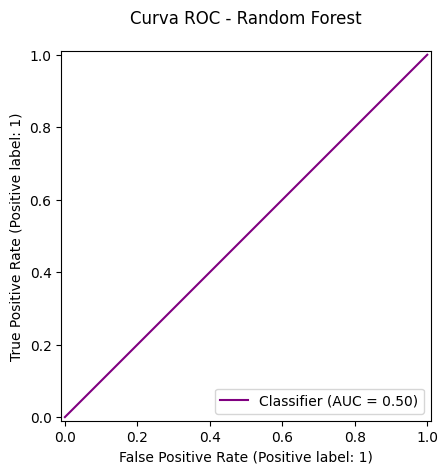

In [221]:

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

dummy = DummyClassifier(strategy = 'most_frequent')
dummy.fit(X_train_scaler, y_train)

y_pred_dummy = dummy.predict(X_test_scaler)

#Accuracy - qué porcentaje fueron correctas?
print("Accuracy:", accuracy_score(y_test, y_pred_dummy))
#Recall - cuántos clientes que sí se iban se detectaron
#F1 - qué tan equilibrado está el modelo entre precisión y recall
print(classification_report(y_test, y_pred_dummy))
#Falsos negativos - clientes que sí se iban y el modelo no detecto
print(confusion_matrix(y_test, y_pred_dummy))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_dummy)
visualizacion_dummy = ConfusionMatrixDisplay(confusion_matrix = cm,
                                             display_labels = ['No Churn/continua', 'Churn/abandona'])

visualizacion_dummy.plot(cmap='Purples', values_format='d')
plt.title("Matriz de Confusión - DummyClassifier", pad = 20)
plt.show()

#probabilidad curva ROC
y__pred_dummy_proba = dummy.predict_proba(X_test_scaler)[:,1]

#Curva ROC del modelo Random Forest
RocCurveDisplay.from_predictions(y_test, y__pred_dummy_proba, color = 'purple')
plt.title('Curva ROC - Random Forest', pad = 20)
plt.show()

# **Creación de modelos para comparación**